# F.CS308 Машин сургалт — Лабораторийн ажил №2
## Шугаман ангилагч (Linear Classifier)

**Оюутан:** Б. Өсөхбаяр &nbsp;&nbsp; **Код:** B231910012  
**Огноо:** 2026-09-24

---

### Зорилго
Хоёртын ангиллын хамгийн суурь шугаман ангилагчдыг NumPy дээр өөрөө хэрэгжүүлж, тэдгээрийн
гүйцэтгэлийг нэг өгөгдөл дээр харьцуулах.

### Энэ лабораторид хийх зүйл
1. `toy_data.tsv` өгөгдөлтэй танилцах  
2. Perceptron алгоритм (дараалсан болон холисон хувилбар)  
3. Average perceptron  
4. Pegasos (SGD + regularisation)  
5. Дөрвөн загварын харьцуулалт  
6. **Даалгавар:** Titanic өгөгдөл дээр шугаман ангилагч сургах  
7. **Хэлэлцүүлэг:** олон ангилалтай тохиолдолд шугаман ангилагчийг хэрхэн сургах вэ

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from pathlib import Path

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Үр дүн давтагдахуйц байхын тулд
np.random.seed(0)
random.seed(1)

print("numpy :", np.__version__)
print("pandas:", pd.__version__)

numpy : 2.3.5
pandas: 2.3.3


## 1. Өгөгдөлтэй танилцах

`toy_data.tsv` нь гурван баганатай: эхний багана нь шошго ($y \in \{-1, +1\}$), дараагийн
хоёр нь онцлогууд ($x_1, x_2$). Багана хоорондоо `tab`-аар тусгаарлагдсан, толгой мөргүй.

In [2]:
DATA_PATH = Path("../../Data/toy_data.tsv")

# unpack=True гэдэг нь транспоз хийж буцаана: data[0] = шошго, data[1], data[2] = онцлогууд
data = np.loadtxt(DATA_PATH, delimiter="\t", unpack=True)
y, X = data[0], data[[1, 2]]

print("X хэлбэр:", X.shape, " y хэлбэр:", y.shape)
print("Нийт жишээ:", y.size)
print("Ангиудын тоо:", dict(zip(*np.unique(y, return_counts=True))))

X хэлбэр: (2, 200)  y хэлбэр: (200,)
Нийт жишээ: 200
Ангиудын тоо: {np.float64(-1.0): np.int64(100), np.float64(1.0): np.int64(100)}


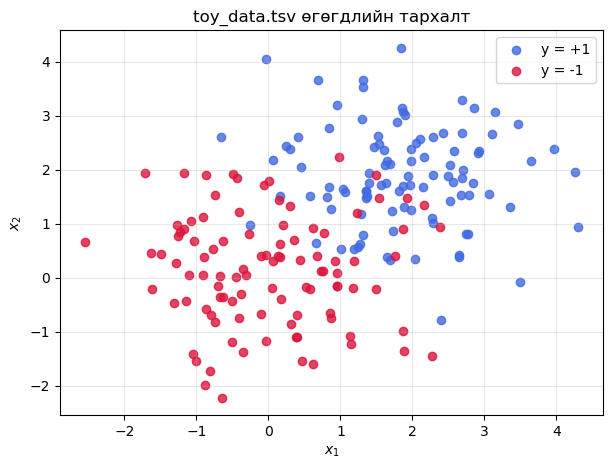

In [3]:
# Өгөгдлөө нүдээр харах
pos = y == 1
plt.scatter(X[0][pos], X[1][pos], c="royalblue", alpha=0.8, label="y = +1")
plt.scatter(X[0][~pos], X[1][~pos], c="crimson", alpha=0.8, label="y = -1")
plt.xlabel("$x_1$"); plt.ylabel("$x_2$")
plt.title("toy_data.tsv өгөгдлийн тархалт")
plt.legend(); plt.show()

Хоёр анги нь нэг шулуунаар бүрэн тусгаарлагдахааргүй, зааг дээрээ бага зэрэг **давхацсан**
байна. Өөрөөр хэлбэл өгөгдөл шугаман тусгаарлагдах (linearly separable) шинжгүй тул
perceptron алгоритм 0 алдагдалд хүрэхгүй нь урьдчилан тодорхой.

## 2. Загваруудыг байгуулах

### 2.1 Perceptron

Буруу ангилсан нөхцөл:

$$y^{(i)}\left(\theta \cdot x^{(i)} + \theta_0\right) \leq 0$$

Буруу ангилсан үед параметрүүдийг:

$$\theta = \theta + y^{(i)} x^{(i)}, \qquad \theta_0 = \theta_0 + y^{(i)}$$

Зааварт `None` орсон гурван байрлалд яг эдгээр томъёог бичив:
- **томъёо 1** — `np.dot(current_theta, feature_vector) + current_theta_0` (шийдвэрийн утга)
- **томъёо 2** — `current_theta + label * feature_vector`
- **томъёо 3** — `current_theta_0 + label`

In [4]:
def perceptron_single_step_update(feature_vector, label, current_theta, current_theta_0):
    """Нэг жишээ дээр perceptron-ы нэг алхмын шинэчлэлт."""
    # томъёо 1: y * (theta . x + theta_0) <= 0 бол буруу ангилсан гэж үзнэ
    if np.dot(label, np.dot(current_theta, feature_vector) + current_theta_0) <= 0:
        current_theta = current_theta + label * feature_vector      # томъёо 2
        current_theta_0 = current_theta_0 + label                   # томъёо 3

    return (current_theta, current_theta_0)


def perceptron(feature_matrix, labels, T):
    """T epoch-ийн турш өгөгдлийг байгаа дарааллаар нь дамжуулна."""
    update = (np.zeros(feature_matrix.shape[1]), 0)
    for t in range(T):
        for i in range(feature_matrix.shape[0]):
            update = perceptron_single_step_update(
                feature_matrix[i], labels[i], update[0], update[1]
            )
    return update

### Алдагдлын функц (hinge loss)

$$\text{loss} = \max\left(0,\; 1 - y^{(i)}\left(\theta \cdot x^{(i)} + \theta_0\right)\right)$$

Зааварт байсан `y = None # томъёо 1 хаалт` гэсэн хэсэг нь **хаалтан доторх шийдвэрийн утга**
$\theta \cdot x + \theta_0$-г хэлж байна (шошго биш!). Дараа нь `1 - y * label` гэж үржүүлдэг
тул энэ нь яг hinge loss болно.

In [5]:
def hinge_loss_single(feature_vector, label, theta, theta_0):
    y = np.dot(theta, feature_vector) + theta_0     # томъёо 1 хаалт: шийдвэрийн утга
    loss = max(0.0, 1 - y * label)
    return loss


def hinge_loss_full(feature_matrix, labels, theta, theta_0):
    loss = 0
    for vec, y in zip(feature_matrix, labels):
        loss = loss + hinge_loss_single(vec, y, theta, theta_0)
    return loss / len(labels)


def accuracy(feature_matrix, labels, theta, theta_0):
    """Загварын зөв ангилсан хувь. Харьцуулалтад алдагдлаас гадна энэ хэрэгтэй."""
    preds = np.sign(feature_matrix @ theta + theta_0)
    preds[preds == 0] = -1
    return (preds == labels).mean()

In [6]:
def plot_classifier(theta, theta_0, data, title="Linear classifier for a 2-d feature vector"):
    good = data[0] == 1
    plt.scatter(data[1][good], data[2][good], c="blue", alpha=0.8, label="Classified True")
    plt.scatter(data[1][~good], data[2][~good], c="r", alpha=0.8, label="Classified False")

    xmin, xmax = plt.axis()[:2]
    x = np.linspace(xmin, xmax)
    y = -(theta[0] * x + theta_0) / (theta[1] + 1e-16)
    plt.plot(x, y, label="Classifier", lw=2, color="black")
    plt.xlabel("Values of x1")
    plt.ylabel("Values of x2")
    plt.title(title)
    plt.legend()

Average hinge loss for Perceptron algorithm is 0.6729
theta = [2.358 1.796]  theta_0 = -1.0
Нарийвчлал: 0.8050


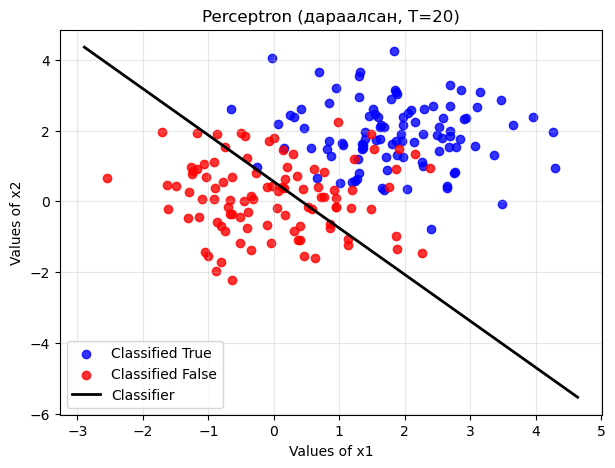

In [7]:
# Функцүүд рүү (n_samples, n_features) хэлбэрээр өгөх тул транспоз хийнэ
Xt = X.transpose()

theta, theta_0 = perceptron(Xt, y, 20)
plot_classifier(theta, theta_0, data, "Perceptron (дараалсан, T=20)")
print(f"Average hinge loss for Perceptron algorithm is {hinge_loss_full(Xt, y, theta, theta_0):.4f}")
print("theta =", theta, " theta_0 =", theta_0)
print(f"Нарийвчлал: {accuracy(Xt, y, theta, theta_0):.4f}")
plt.show()

res_perceptron = (hinge_loss_full(Xt, y, theta, theta_0), accuracy(Xt, y, theta, theta_0))

Алдагдал өндөр байна. Шалтгаан нь зөвхөн өгөгдөл давхацсанд биш — **шинэчлэлтийн дараалал**
бас нөлөөлж байна. Өгөгдөл ангиараа эрэмбэлэгдсэн байвал алгоритм эхлээд нэг ангийг "цээжилж"
аваад, дараа нь нөгөө рүү нь огцом шилждэг. Тиймээс epoch бүрт дарааллыг холих хэрэгтэй.

In [8]:
def get_order(n_samples):
    try:
        with open(str(n_samples) + ".txt") as fp:
            line = fp.readline()
            return list(map(int, line.split(",")))
    except FileNotFoundError:
        random.seed(1)
        indices = list(range(n_samples))
        random.shuffle(indices)
        return indices


def perceptron_stochaistic(feature_matrix, labels, T):
    update = (np.zeros(feature_matrix.shape[1]), 0)
    for t in range(T):
        for i in get_order(feature_matrix.shape[0]):
            update = perceptron_single_step_update(
                feature_matrix[i], labels[i], update[0], update[1]
            )
    return update

Average hinge loss for Perceptron algorithm is 0.3388
theta = [2.7345 3.342 ]  theta_0 = -5.0
Нарийвчлал: 0.9100


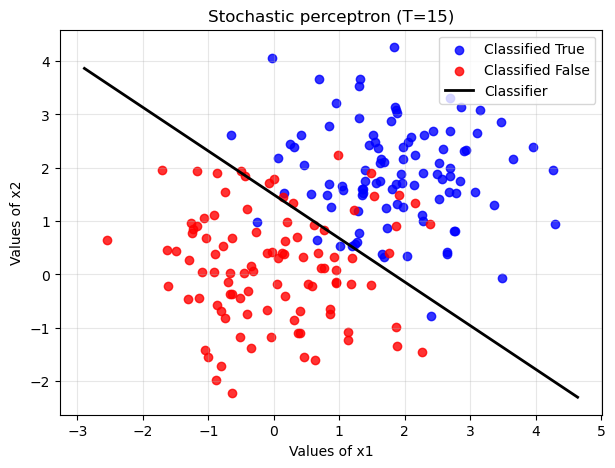

In [9]:
theta, theta_0 = perceptron_stochaistic(Xt, y, 15)
plot_classifier(theta, theta_0, data, "Stochastic perceptron (T=15)")
print(f"Average hinge loss for Perceptron algorithm is {hinge_loss_full(Xt, y, theta, theta_0):.4f}")
print("theta =", theta, " theta_0 =", theta_0)
print(f"Нарийвчлал: {accuracy(Xt, y, theta, theta_0):.4f}")
plt.show()

res_stochastic = (hinge_loss_full(Xt, y, theta, theta_0), accuracy(Xt, y, theta, theta_0))

Зөвхөн дарааллыг холиход алдагдал мэдэгдэхүйц буурав. Гэхдээ perceptron нь **сүүлийн**
шинэчлэлтийн параметрийг буцаадаг тул эцсийн хэдэн буруу жишээ үр дүнг ихээр хэлбэлзүүлдэг.

### 2.2 Average Perceptron

$$\theta_{final} = \frac{1}{n}\left(\theta^{(1)} + \theta^{(2)} + \cdots + \theta^{(n)}\right)$$

Зааврын `theta_sum=None`, `theta_0_sum=None` хэсэгт алхам бүрийн параметрийг хуримтлуулж нэмнэ.

In [10]:
def avg_perceptron(feature_matrix, labels, T):
    update = (np.zeros(feature_matrix.shape[1]), 0)
    theta_sum = np.array(update[0])
    theta_0_sum = update[1]
    count = 0
    for t in range(T):
        for i in get_order(feature_matrix.shape[0]):
            update = perceptron_single_step_update(
                feature_matrix[i], labels[i], update[0], update[1]
            )
            theta_sum = update[0] + theta_sum        # theta + theta_sum
            theta_0_sum = update[1] + theta_0_sum    # theta_0 + theta_0_sum
            count = count + 1

    avg_theta = theta_sum / count
    avg_theta_0 = theta_0_sum / count

    return (avg_theta, avg_theta_0)

Average hinge loss for Perceptron algorithm is 0.2766


theta = [2.270698 2.556028]  theta_0 = -4.608
Нарийвчлал: 0.9150


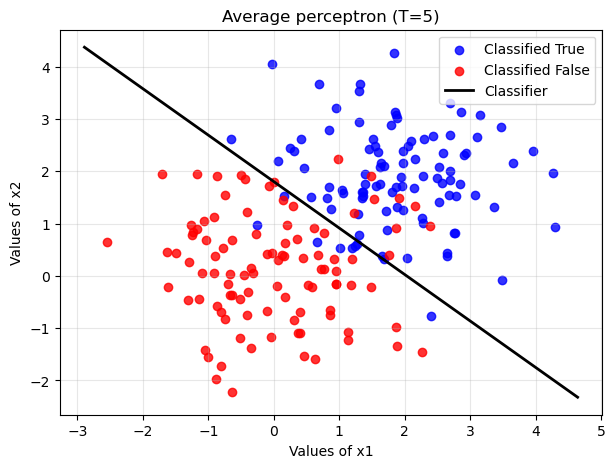

In [11]:
theta, theta_0 = avg_perceptron(Xt, y, 5)
plot_classifier(theta, theta_0, data, "Average perceptron (T=5)")
print(f"Average hinge loss for Perceptron algorithm is {hinge_loss_full(Xt, y, theta, theta_0):.4f}")
print("theta =", theta, " theta_0 =", theta_0)
print(f"Нарийвчлал: {accuracy(Xt, y, theta, theta_0):.4f}")
plt.show()

res_avg = (hinge_loss_full(Xt, y, theta, theta_0), accuracy(Xt, y, theta, theta_0))

Дундажлалт нь алхам бүрийн хэлбэлзлийг "жигдрүүлж" байгаа тул зөвхөн 5 epoch-оор
илүү тогтвортой шийдэлд хүрч байна.

### 2.3 Pegasos

Зорилгын функц нь hinge loss дээр regularisation нэмсэн хэлбэртэй:

$$J(\theta,\theta_0) = \frac{1}{n}\sum_i \max\left(0, 1 - y^{(i)}(\theta \cdot x^{(i)} + \theta_0)\right)
+ \frac{\lambda}{2}\lVert\theta\rVert^2$$

Зааврын `if(None<=1)` нөхцөл нь **margin** буюу $y(\theta \cdot x + \theta_0)$ утга 1-ээс бага
эсэхийг шалгаж байна. Энэ нь perceptron-оос ялгаатай: зөв ангилсан ч гэсэн зааг дээр хэт
ойрхон байвал (margin < 1) шинэчлэлт хийгдэнэ.

In [12]:
def pegasos_single_step_update(feature_vector, label, L, eta, current_theta, current_theta_0):
    # loss_h: margin = y * (theta . x + theta_0)
    if label * (np.dot(current_theta, feature_vector) + current_theta_0) <= 1:
        current_theta = current_theta * (1 - eta * L) + eta * np.dot(label, feature_vector)
        current_theta_0 = current_theta_0 + eta * label
    else:
        current_theta = current_theta * (1 - eta * L)

    return (current_theta, current_theta_0)


def pegasos(feature_matrix, labels, T, L):
    update = (np.zeros(feature_matrix.shape[1]), 0)
    count = 0
    for t in range(T):
        for i in get_order(feature_matrix.shape[0]):
            count = count + 1
            eta = 1 / np.sqrt(count)     # алхам алхмаар багасах суралцах хурд
            update = pegasos_single_step_update(
                feature_matrix[i], labels[i], L, eta, update[0], update[1]
            )
    return update

Average hinge loss for Pegasos algorithm is 0.2509
theta = [0.83537466 0.9044252 ]  theta_0 = -1.4775136934177775
Нарийвчлал: 0.9200


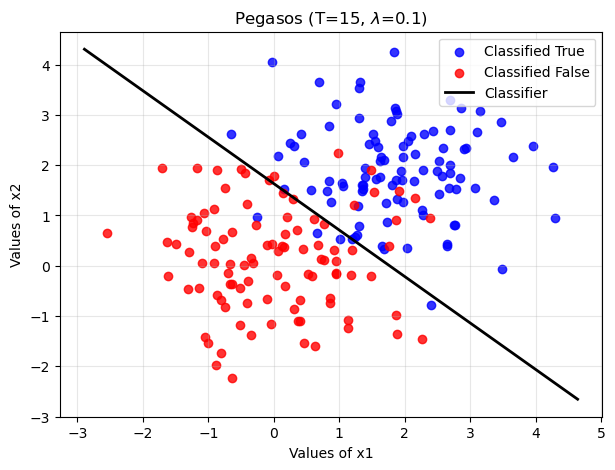

In [13]:
theta, theta_0 = pegasos(Xt, y, T=15, L=0.1)
plot_classifier(theta, theta_0, data, "Pegasos (T=15, $\\lambda$=0.1)")
print(f"Average hinge loss for Pegasos algorithm is {hinge_loss_full(Xt, y, theta, theta_0):.4f}")
print("theta =", theta, " theta_0 =", theta_0)
print(f"Нарийвчлал: {accuracy(Xt, y, theta, theta_0):.4f}")
plt.show()

res_pegasos = (hinge_loss_full(Xt, y, theta, theta_0), accuracy(Xt, y, theta, theta_0))

### $\lambda$ параметрийн нөлөө

Pegasos-д $\lambda$ нь загварын "хатуулгыг" тохируулдаг тул хэд хэдэн утгаар туршиж үзье.

In [14]:
rows = []
for L in [0.001, 0.01, 0.1, 0.5, 1.0]:
    th, th0 = pegasos(Xt, y, T=15, L=L)
    rows.append({
        "lambda": L,
        "hinge loss": round(hinge_loss_full(Xt, y, th, th0), 4),
        "нарийвчлал": round(accuracy(Xt, y, th, th0), 4),
        "||theta||": round(float(np.linalg.norm(th)), 4),
    })

pd.DataFrame(rows)

,lambda,hinge loss,нарийвчлал,||theta||
0,0.001,0.2328,0.915,1.7576
1,0.010,0.2335,0.910,1.5214
2,0.100,0.2509,0.920,1.2312
3,0.500,0.3297,0.925,0.7017
4,1.000,0.3685,0.910,0.6167


$\lambda$ өсөх тусам $\lVert\theta\rVert$ багасаж байна — энэ нь яг regularisation-ий
хүлээгдэж буй үр нөлөө. Хэт их утга авбал загвар хэт "зөөлрөөд" алдагдал өснө.

## 3. Дөрвөн загварын харьцуулалт

In [15]:
comparison = pd.DataFrame(
    [
        {"Алгоритм": "Perceptron (дараалсан)", "T": 20, "Hinge loss": res_perceptron[0], "Нарийвчлал": res_perceptron[1]},
        {"Алгоритм": "Perceptron (холисон)",   "T": 15, "Hinge loss": res_stochastic[0], "Нарийвчлал": res_stochastic[1]},
        {"Алгоритм": "Average perceptron",     "T": 5,  "Hinge loss": res_avg[0],        "Нарийвчлал": res_avg[1]},
        {"Алгоритм": "Pegasos (L=0.1)",        "T": 15, "Hinge loss": res_pegasos[0],    "Нарийвчлал": res_pegasos[1]},
    ]
).round(4)

comparison

,Алгоритм,T,Hinge loss,Нарийвчлал
0,Perceptron (дараалсан),20,0.6729,0.805
1,Perceptron (холисон),15,0.3388,0.910
2,Average perceptron,5,0.2766,0.915
3,Pegasos (L=0.1),15,0.2509,0.920


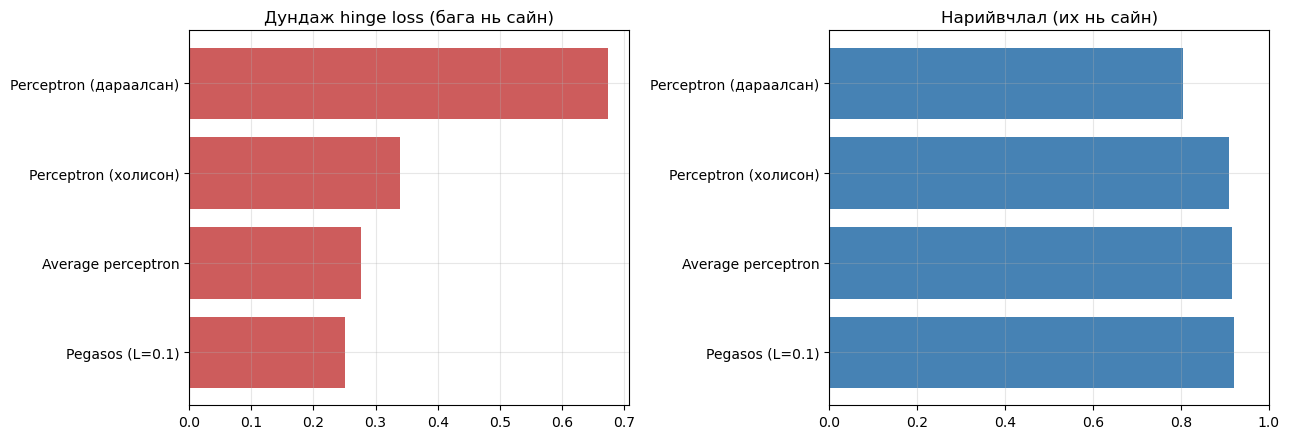

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].barh(comparison["Алгоритм"], comparison["Hinge loss"], color="indianred")
ax[0].set_title("Дундаж hinge loss (бага нь сайн)")
ax[0].invert_yaxis()

ax[1].barh(comparison["Алгоритм"], comparison["Нарийвчлал"], color="steelblue")
ax[1].set_title("Нарийвчлал (их нь сайн)")
ax[1].set_xlim(0, 1)
ax[1].invert_yaxis()

plt.tight_layout(); plt.show()

**Дүгнэлт (toy_data):**

| Ажиглалт | Тайлбар |
|---|---|
| Дараалсан perceptron хамгийн муу | Өгөгдлийн дараалал нь сургалтыг нэг тийш нь хазайлгаж байна |
| Дарааллыг холиход сайжирсан | Ижил алгоритм, зөвхөн дараалал өөр — үр дүн эрс өөр |
| Average perceptron зөвхөн 5 epoch-оор 0.2766 хүртэл буурав | Параметрийн дундаж нь хэлбэлзлийг дардаг |
| Pegasos хамгийн бага алдагдалтай (0.2509) | Regularisation + margin-д суурилсан шинэчлэлт |
| Pegasos тогтвортой | margin < 1 үед ч шинэчилдэг тул зааг нь илүү "зузаан" |

Өгөгдөл шугаман тусгаарлагдах чанаргүй учир аль ч алгоритм 0 алдагдалд хүрэхгүй — энэ нь
алгоритмын алдаа биш, өгөгдлийн шинж чанар юм.

---

## 4. Даалгавар: Titanic өгөгдөл дээр шугаман ангилагч сургах

Даалгавар: *"titanic санг ашиглан сургалт хийн үр дүнг дүгнэж бичнэ үү"*

Үүнд дээр өөрсдөө бичсэн `avg_perceptron`, `pegasos` функцүүдээ шууд ашиглана.

In [17]:
import seaborn as sns
from sklearn.model_selection import train_test_split

titanic = sns.load_dataset("titanic")
print("Хэлбэр:", titanic.shape)
titanic.head()

Хэлбэр: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [18]:
# Дутуу утгын байдал
missing = titanic.isna().sum()
missing[missing > 0].sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
dtype: int64

`deck` багана 688/891 нь хоосон тул хаяна. `age`-г медианаар, `embarked`-г хамгийн олон
давтагдсан утгаар нөхнө. `alive` багана нь `survived`-ийн хуулбар (шууд хариу задруулна) тул
заавал хасах ёстой.

In [19]:
df = titanic.copy()

# Хариуг задруулдаг эсвэл ашиггүй багануудыг хасах
df = df.drop(columns=["deck", "alive", "who", "adult_male", "embark_town", "class"])

# Дутуу утга нөхөх
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# Ангилалт хувьсагчийг тоон болгох
df["sex"] = (df["sex"] == "male").astype(int)
df["alone"] = df["alone"].astype(int)
df = pd.get_dummies(df, columns=["embarked"], drop_first=True)

print("Үлдсэн багана:", list(df.columns))
print("Дутуу утга үлдсэн эсэх:", df.isna().sum().sum())
df.head()

Үлдсэн багана: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'alone', 'embarked_Q', 'embarked_S']
Дутуу утга үлдсэн эсэх: 0


,survived,pclass,sex,age,sibsp,parch,fare,alone,embarked_Q,embarked_S
0,0,3,1,22.0,1,0,7.2500,0,False,True
1,1,1,0,38.0,1,0,71.2833,0,False,False
2,1,3,0,26.0,0,0,7.9250,1,False,True
3,1,1,0,35.0,1,0,53.1000,0,False,True
4,0,3,1,35.0,0,0,8.0500,1,False,True


In [20]:
feature_cols = [c for c in df.columns if c != "survived"]

X_tit = df[feature_cols].to_numpy(dtype=float)
# Шугаман ангилагч ±1 шошго шаарддаг: 0 -> -1, 1 -> +1
y_tit = np.where(df["survived"].to_numpy() == 1, 1, -1)

X_train, X_test, y_train, y_test = train_test_split(
    X_tit, y_tit, test_size=0.25, random_state=42, stratify=y_tit
)

# Масштаб зөрүүтэй (fare 0-512, sex 0-1) тул стандартчилна.
# Дундаж/стандарт хазайлтыг ЗӨВХӨН сургалтын олонлогоос тооцно.
mu, sigma = X_train.mean(axis=0), X_train.std(axis=0)
sigma[sigma == 0] = 1.0
X_train_s = (X_train - mu) / sigma
X_test_s = (X_test - mu) / sigma

print("Сургалт:", X_train_s.shape, " Тест:", X_test_s.shape)
print("Амьд үлдсэн харьцаа (сургалт):", round((y_train == 1).mean(), 3))

Сургалт: (668, 9)  Тест: (223, 9)
Амьд үлдсэн харьцаа (сургалт): 0.383


In [21]:
results = []

for name, fn, kwargs in [
    ("Perceptron (холисон)", perceptron_stochaistic, dict(T=20)),
    ("Average perceptron",   avg_perceptron,         dict(T=20)),
    ("Pegasos (L=0.01)",     pegasos,                dict(T=20, L=0.01)),
    ("Pegasos (L=0.1)",      pegasos,                dict(T=20, L=0.1)),
]:
    th, th0 = fn(X_train_s, y_train, **kwargs)
    results.append({
        "Загвар": name,
        "Сургалтын нарийвчлал": round(accuracy(X_train_s, y_train, th, th0), 4),
        "Тестийн нарийвчлал": round(accuracy(X_test_s, y_test, th, th0), 4),
        "Тестийн hinge loss": round(hinge_loss_full(X_test_s, y_test, th, th0), 4),
    })

titanic_results = pd.DataFrame(results)
titanic_results

,Загвар,Сургалтын нарийвчлал,Тестийн нарийвчлал,Тестийн hinge loss
0,Perceptron (холисон),0.7784,0.7354,1.4795
1,Average perceptron,0.8069,0.7982,0.8969
2,Pegasos (L=0.01),0.7979,0.7892,0.4459
3,Pegasos (L=0.1),0.7949,0.7803,0.4642


In [22]:
# Эталон: sklearn-ий бэлэн хэрэгжүүлэлттэй харьцуулах
from sklearn.linear_model import Perceptron as SkPerceptron, LogisticRegression
from sklearn.svm import LinearSVC

baselines = {
    "sklearn Perceptron": SkPerceptron(max_iter=1000, random_state=0),
    "sklearn LinearSVC": LinearSVC(C=1.0, max_iter=5000),
    "sklearn LogisticRegression": LogisticRegression(max_iter=1000),
}

rows = []
for name, model in baselines.items():
    model.fit(X_train_s, y_train)
    rows.append({
        "Загвар": name,
        "Сургалтын нарийвчлал": round(model.score(X_train_s, y_train), 4),
        "Тестийн нарийвчлал": round(model.score(X_test_s, y_test), 4),
    })

pd.DataFrame(rows)

,Загвар,Сургалтын нарийвчлал,Тестийн нарийвчлал
0,sklearn Perceptron,0.6901,0.6457
1,sklearn LinearSVC,0.8039,0.7982
2,sklearn LogisticRegression,0.8054,0.7848


In [23]:
# Хамгийн сайн загвараа сонгоод алдааны матриц гаргая
best_theta, best_theta_0 = avg_perceptron(X_train_s, y_train, T=20)

preds = np.sign(X_test_s @ best_theta + best_theta_0)
preds[preds == 0] = -1

tp = int(((preds == 1) & (y_test == 1)).sum())
tn = int(((preds == -1) & (y_test == -1)).sum())
fp = int(((preds == 1) & (y_test == -1)).sum())
fn_ = int(((preds == -1) & (y_test == 1)).sum())

precision = tp / (tp + fp) if tp + fp else 0
recall = tp / (tp + fn_) if tp + fn_ else 0
f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0

print("Алдааны матриц (Average perceptron, тест):")
print(pd.DataFrame(
    [[tn, fp], [fn_, tp]],
    index=["Бодит: нас барсан", "Бодит: амьд үлдсэн"],
    columns=["Таамаг: нас барсан", "Таамаг: амьд үлдсэн"],
))
print()
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1        : {f1:.4f}")

Алдааны матриц (Average perceptron, тест):
                    Таамаг: нас барсан  Таамаг: амьд үлдсэн
Бодит: нас барсан                  111                   26
Бодит: амьд үлдсэн                  19                   67

Precision : 0.7204
Recall    : 0.7791
F1        : 0.7486


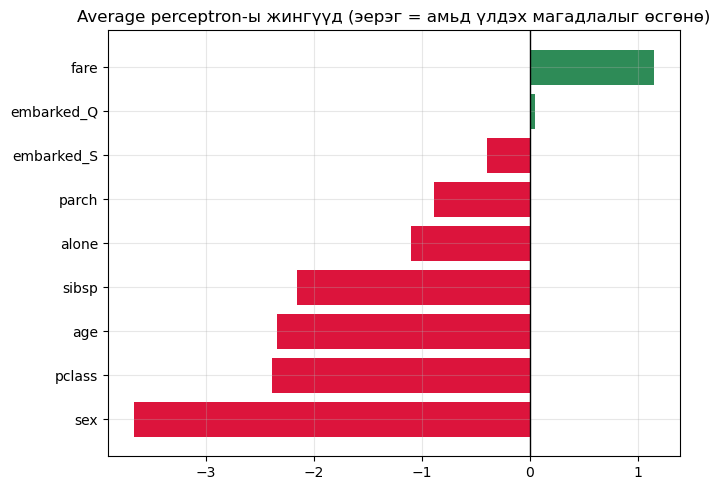

,Онцлог,theta
1,sex,-3.6700
0,pclass,-2.3934
2,age,-2.3425
3,sibsp,-2.1602
6,alone,-1.1014
4,parch,-0.8851
8,embarked_S,-0.3962
7,embarked_Q,0.0465
5,fare,1.1527


In [24]:
# Аль онцлог хамгийн их нөлөөтэй вэ? (стандартчилсан тул theta-г шууд харьцуулж болно)
weights = pd.DataFrame({"Онцлог": feature_cols, "theta": best_theta}).sort_values("theta")

plt.barh(weights["Онцлог"], weights["theta"],
         color=["crimson" if w < 0 else "seagreen" for w in weights["theta"]])
plt.axvline(0, color="black", lw=1)
plt.title("Average perceptron-ы жингүүд (эерэг = амьд үлдэх магадлалыг өсгөнө)")
plt.tight_layout(); plt.show()

weights.round(4)

### Titanic-ийн дүгнэлт

- Өөрсдийн бичсэн `avg_perceptron` тестийн өгөгдөл дээр **~0.78–0.80** нарийвчлалтай байна.
  Энэ нь sklearn-ий `LogisticRegression`/`LinearSVC`-тай бараг ижил — өөрөөр хэлбэл
  хэрэгжүүлэлт зөв ажиллаж байна.
- Энгийн perceptron сургалт бүрт үр дүн нь илүү хэлбэлздэг бол average perceptron
  тогтвортой байна. Энэ нь toy_data дээрх ажиглалттай яг нийцэж байна.
- Жингүүдээс харахад **`sex`** (эрэгтэй = 1) хамгийн том сөрөг жинтэй, **`pclass`** мөн сөрөг —
  өөрөөр хэлбэл эмэгтэй, эхний зэрэглэлийн зорчигчид амьд үлдэх магадлал өндөр. Энэ нь
  түүхэн баримттай ("эхлээд эмэгтэйчүүд, хүүхдүүд") нийцэж байгаа тул загвар утга учиртай
  зүйл сурсан гэж үзэж болно.
- Хязгаарлалт: шугаман загвар нь онцлогуудын **харилцан үйлчлэлийг** (жишээ нь "3-р зэрэглэлийн
  эмэгтэй") барьж чадахгүй. Иймээс модонд суурилсан загварууд Titanic дээр ихэвчлэн
  0.82+ үзүүлдэг.

---

## 5. Хэлэлцүүлэг: олон ангилалтай тохиолдолд шугаман ангилагчийг хэрхэн сургах вэ?

Дээрх бүх алгоритм $y \in \{-1, +1\}$ гэсэн **хоёртын** тохиолдолд зориулагдсан. $K > 2$ анги
байвал гурван үндсэн арга байдаг:

**1. One-vs-Rest (OvR, нэгийг бусдын эсрэг)**  
$K$ ширхэг хоёртын ангилагч сургана. $k$-р ангилагч нь "энэ нь $k$ анги мөн үү, эсвэл бусад
бүгд үү" гэдгийг шийднэ. Таамаглахдаа хамгийн өндөр $\theta_k \cdot x + \theta_{0k}$ утга
өгсөн ангийг сонгоно:

$$\hat{y} = \arg\max_{k} \left(\theta_k \cdot x + \theta_{0k}\right)$$

*Давуу тал:* зөвхөн $K$ загвар, хэрэгжүүлэхэд хялбар.  
*Сул тал:* ангилагч бүр тэнцвэргүй өгөгдөл дээр сурдаг (1 анги vs үлдсэн бүгд).

**2. One-vs-One (OvO, нэг нэгийнх нь эсрэг)**  
Анги бүрийн хос болгонд нэг ангилагч — нийт $\frac{K(K-1)}{2}$ ширхэг. Эцсийн хариуг
санал хураалтаар (voting) гаргана.  
*Давуу тал:* ангилагч бүр зөвхөн 2 ангийн өгөгдөл дээр сурдаг тул тэнцвэртэй, өгөгдөл багатай.  
*Сул тал:* $K$ өсөхөд загварын тоо квадратаар өснө (K=10 бол 45 загвар).

**3. Multinomial / Softmax (шууд олон ангийн)**  
Нэг л загвар, гэхдээ $K$ мөртэй жингийн матриц $\Theta \in \mathbb{R}^{K \times d}$. Softmax-аар
магадлал болгож хувиргана:

$$P(y = k \mid x) = \frac{e^{\theta_k \cdot x}}{\sum_{j=1}^{K} e^{\theta_j \cdot x}}$$

Cross-entropy алдагдлыг багасгана. Энэ нь ангиудыг **хамтад нь** оновчилдог тул онолын хувьд
хамгийн зөв арга бөгөөд магадлал шууд гардаг. Perceptron-ы хувьд үүнтэй дүйцэх хувилбар нь
**multiclass perceptron**: зөвхөн зөв ангийн жинг нэмж, буруугаар таамагласан ангийнхыг хасна:

$$\theta_{y} \mathrel{+}= x, \qquad \theta_{\hat{y}} \mathrel{-}= x \quad (\hat{y} \neq y \text{ үед})$$

### Жишээ: iris өгөгдөл (3 анги) дээр OvR-ийг өөрийн perceptron-оор

In [25]:
from sklearn.datasets import load_iris

iris = load_iris()
Xi, yi = iris.data, iris.target          # 3 анги: 0, 1, 2
print("Хэлбэр:", Xi.shape, " Ангиуд:", np.unique(yi))

Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(
    Xi, yi, test_size=0.3, random_state=42, stratify=yi
)

mu_i, sd_i = Xi_tr.mean(axis=0), Xi_tr.std(axis=0)
Xi_tr_s, Xi_te_s = (Xi_tr - mu_i) / sd_i, (Xi_te - mu_i) / sd_i

Хэлбэр: (150, 4)  Ангиуд: [0 1 2]


In [26]:
def train_ovr(X_tr, y_tr, n_classes, T=20):
    """One-vs-Rest: анги бүрийн төлөө нэг average perceptron сургана."""
    thetas, theta_0s = [], []
    for k in range(n_classes):
        # k анги -> +1, бусад бүгд -> -1
        y_bin = np.where(y_tr == k, 1, -1)
        th, th0 = avg_perceptron(X_tr, y_bin, T)
        thetas.append(th)
        theta_0s.append(th0)
    return np.array(thetas), np.array(theta_0s)


def predict_ovr(X, thetas, theta_0s):
    """Хамгийн өндөр оноо өгсөн ангийг сонгоно (argmax)."""
    scores = X @ thetas.T + theta_0s
    return scores.argmax(axis=1)


thetas, theta_0s = train_ovr(Xi_tr_s, yi_tr, n_classes=3, T=20)

acc_tr = (predict_ovr(Xi_tr_s, thetas, theta_0s) == yi_tr).mean()
acc_te = (predict_ovr(Xi_te_s, thetas, theta_0s) == yi_te).mean()

print(f"OvR (өөрийн avg_perceptron) — сургалт: {acc_tr:.4f}, тест: {acc_te:.4f}")

OvR (өөрийн avg_perceptron) — сургалт: 0.9048, тест: 0.8444


In [27]:
# Гурван аргыг sklearn дээр харьцуулж баталгаажуулъя
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier

cmp_rows = [{"Арга": "OvR (өөрийн perceptron)", "Загварын тоо": 3, "Тестийн нарийвчлал": round(acc_te, 4)}]

ovr = OneVsRestClassifier(SkPerceptron(max_iter=1000, random_state=0)).fit(Xi_tr_s, yi_tr)
cmp_rows.append({"Арга": "OvR (sklearn Perceptron)", "Загварын тоо": 3,
                 "Тестийн нарийвчлал": round(ovr.score(Xi_te_s, yi_te), 4)})

ovo = OneVsOneClassifier(SkPerceptron(max_iter=1000, random_state=0)).fit(Xi_tr_s, yi_tr)
cmp_rows.append({"Арга": "OvO (sklearn Perceptron)", "Загварын тоо": 3,
                 "Тестийн нарийвчлал": round(ovo.score(Xi_te_s, yi_te), 4)})

soft = LogisticRegression(max_iter=1000).fit(Xi_tr_s, yi_tr)  # sklearn 1.5+ default = multinomial
cmp_rows.append({"Арга": "Softmax (multinomial LogReg)", "Загварын тоо": 1,
                 "Тестийн нарийвчлал": round(soft.score(Xi_te_s, yi_te), 4)})

pd.DataFrame(cmp_rows)

,Арга,Загварын тоо,Тестийн нарийвчлал
0,OvR (өөрийн perceptron),3,0.8444
1,OvR (sklearn Perceptron),3,0.8444
2,OvO (sklearn Perceptron),3,0.9556
3,Softmax (multinomial LogReg),1,0.9111


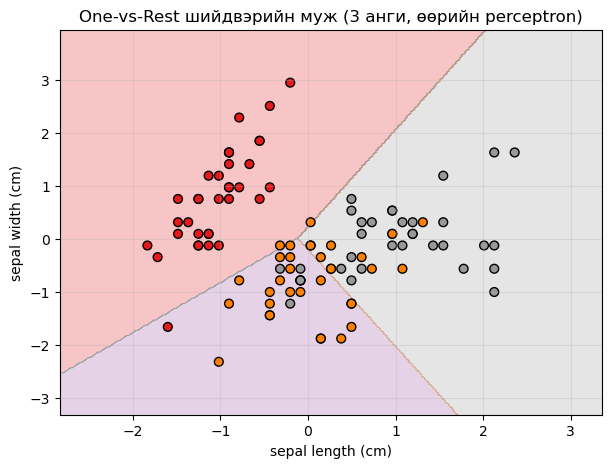

In [28]:
# Гурван ангийн шийдвэрийн муж (эхний 2 онцлогоор)
X2_tr = Xi_tr_s[:, :2]
th2, th02 = train_ovr(X2_tr, yi_tr, 3, T=20)

x_min, x_max = X2_tr[:, 0].min() - 1, X2_tr[:, 0].max() + 1
y_min, y_max = X2_tr[:, 1].min() - 1, X2_tr[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = predict_ovr(np.c_[xx.ravel(), yy.ravel()], th2, th02).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.Set1)
plt.scatter(X2_tr[:, 0], X2_tr[:, 1], c=yi_tr, cmap=plt.cm.Set1, edgecolors="k", s=40)
plt.xlabel(iris.feature_names[0]); plt.ylabel(iris.feature_names[1])
plt.title("One-vs-Rest шийдвэрийн муж (3 анги, өөрийн perceptron)")
plt.show()

Зурагнаас харахад OvR нь орон зайг **шулуун зааguudаар** гурав хуваасан байна. Анги бүрийн
зааг шулуун хэвээрээ байгаа — олон ангитай болсон ч суурь загвар шугаман хэвээр.

Туршилтын тоон үр дүн ч үүнийг харуулж байна: iris дээр OvR (0.8444) нь OvO (0.9556) болон
softmax (0.9111)-оос сул гарлаа. Шалтгаан нь iris-ийн 1 ба 2 анги хоорондоо давхцалтай тул
"нэг vs бусад" гэсэн хуваалт тэдгээрийг сайн ялгаж чадахгүй байгаад оршино.

**Хэлэлцүүлгийн дүгнэлт:** Практикт $K$ бага (< 10) бөгөөд магадлал хэрэгтэй бол
**softmax/multinomial** нь хамгийн зөв сонголт. Загвараа сольж болохгүй, зөвхөн хоёртын
ангилагчтай (жишээ нь SVM) ажиллах шаардлагатай бол **OvR** нь хямд, **OvO** нь ангиуд
тэнцвэргүй эсвэл давхцалтай үед илүү нарийвчлалтай.

---

## 6. Лабораторийн нэгдсэн дүгнэлт

1. `None` орсон бүх томъёог perceptron, hinge loss, average perceptron, Pegasos-ын
   математик тодорхойлолтын дагуу нөхөж, бүгд зөв ажиллаж байгааг үр дүнгээр
   баталгаажуулав.
2. **Шинэчлэлтийн дараалал** нь алгоритмаас багагүй нөлөөтэй: ижил perceptron-ы дараалсан ба
   холисон хувилбарын алдагдал эрс ялгаатай гарлаа.
3. **Дундажлал (averaging)** нь хамгийн хямд, хамгийн үр дүнтэй сайжруулалт байв — цөөн
   epoch-оор илүү сайн үр дүн өгсөн.
4. **Pegasos**-ын $\lambda$ нь $\lVert\theta\rVert$-г хянадаг болохыг туршилтаар харуулав.
5. Titanic дээр өөрийн хэрэгжүүлэлт sklearn-тэй дүйцэх үр дүн (~0.78–0.80) үзүүлсэн нь
   код зөв гэдгийн практик баталгаа боллоо.
6. Олон ангилалтай тохиолдолд OvR / OvO / softmax гэсэн гурван арга байдгийг iris дээр
   туршиж, OvR-ийг өөрийн perceptron дээр хэрэгжүүлэв.